# Experiment Tracking con MLflow y Model Registry

Este notebook documenta y verifica los experimentos generados durante la etapa de modelo y experimentación. No vuelve a entrenar los modelos: consulta la información almacenada en `mlflow.db` y `mlruns/`.

La ejecución de entrenamiento que creó estos registros se encuentra en `J_Modelo_y_Experimentacion.ipynb`.

## 1. Objetivo de la trazabilidad

MLflow debe permitir responder qué algoritmo, hiperparámetros, features, semilla, versión de datos y métricas produjeron cada resultado. También debe conservar los artefactos de evaluación y relacionar el modelo seleccionado con el Model Registry.

## 2. Importaciones y conexión

La base SQLite está ubicada en la raíz del proyecto. Por eso este notebook debe abrirse desde esa carpeta.

In [29]:
from pathlib import Path

import mlflow
import pandas as pd
from IPython.display import Image, display
from mlflow.tracking import MlflowClient

PROJECT_ROOT = Path.cwd()
TRACKING_URI = 'sqlite:///mlflow.db'
EXPERIMENT_NAME = 'adult_income_classification'
REGISTERED_MODEL_NAME = 'adult-income-classifier'

if not (PROJECT_ROOT / 'mlflow.db').exists():
    raise FileNotFoundError(
        'No se encontró mlflow.db. Abra el notebook desde la raíz del proyecto.'
    )

mlflow.set_tracking_uri(TRACKING_URI)
cliente_mlflow = MlflowClient(tracking_uri=TRACKING_URI)

print(f'Proyecto: {PROJECT_ROOT}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Proyecto: c:\Users\c3283\Desktop\INCOEX\proyecto de nuevo
Tracking URI: sqlite:///mlflow.db


## 3. Identificación de la sesión registrada

Los siguientes identificadores corresponden a la ejecución realizada después de seleccionar HistGradientBoosting. Se conservan para que la evidencia no se mezcle con ejecuciones anteriores o posteriores.

In [30]:
import json

MANIFEST_PATH = (
    PROJECT_ROOT
    / "resultado_pipeline"
    / "modelo"
    / "manifest_modelo.json"
)

with MANIFEST_PATH.open(encoding="utf-8") as archivo:
    manifiesto = json.load(archivo)

RUN_IDS_SESION = manifiesto["mlflow_run_ids"]

display(
    pd.Series(RUN_IDS_SESION, name='run_id')
    .rename_axis('registro')
    .to_frame()
)

,run_id
registro,
hist_gradient_boosting,b767f6c4b4b2442384538a58ce0eab2b
random_forest,fcaab2053cc84971a2f1b21f4a30cf8a
logistic_regression,337ab731e3044af8a10fa09850ecb68f
dummy_baseline,da1380a3ef5f4456b3a767ab23118925
selected_model,4c5d5fd38b95454caf17f1da24795e1d


## 4. Verificación del experimento

Se comprueba que el experimento exista y se recupera su identificador.

In [31]:
experimento = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experimento is None:
    raise ValueError(f'No existe el experimento {EXPERIMENT_NAME!r}.')

resumen_experimento = pd.Series({
    'nombre': experimento.name,
    'experiment_id': experimento.experiment_id,
    'estado': experimento.lifecycle_stage,
    'ubicación_de_artefactos': experimento.artifact_location,
}, name='valor').to_frame()

display(resumen_experimento)

,valor
nombre,adult_income_classification
experiment_id,1
estado,active
ubicación_de_artefactos,file:c:/Users/c3283/Desktop/INCOEX/proyecto de...


## 5. Tabla general de runs

La tabla permite verificar que cada algoritmo tenga su propio run y que el modelo final tenga un run separado con métricas de test.

In [32]:
runs_experimento = mlflow.search_runs(
    experiment_ids=[experimento.experiment_id],
    order_by=['start_time DESC'],
)

runs_sesion = runs_experimento.loc[
    runs_experimento['run_id'].isin(RUN_IDS_SESION.values())
].copy()

columnas_resumen = [
    'run_id',
    'tags.mlflow.runName',
    'params.algorithm',
    'params.feature_set',
    'params.random_seed',
    'params.data_version',
    'metrics.average_precision',
    'metrics.roc_auc',
    'metrics.f1',
    'metrics.test_average_precision',
    'metrics.test_roc_auc',
    'metrics.test_f1',
]

columnas_disponibles = [
    columna for columna in columnas_resumen
    if columna in runs_sesion.columns
]

display(runs_sesion[columnas_disponibles])
assert len(runs_sesion) == len(RUN_IDS_SESION), (
    'No se encontraron todos los runs correspondientes a esta sesión.'
)

,run_id,tags.mlflow.runName,params.algorithm,params.feature_set,params.random_seed,params.data_version,metrics.average_precision,metrics.roc_auc,metrics.f1,metrics.test_average_precision,metrics.test_roc_auc,metrics.test_f1
0,4c5d5fd38b95454caf17f1da24795e1d,selected_hist_gradient_boosting,hist_gradient_boosting,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,NaN,NaN,NaN,0.840664,0.933158,0.732271
1,da1380a3ef5f4456b3a767ab23118925,cv_dummy_baseline,dummy_baseline,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,0.239419,0.500000,0.000000,NaN,NaN,NaN
2,337ab731e3044af8a10fa09850ecb68f,cv_logistic_regression,logistic_regression,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,0.771286,0.908217,0.682253,NaN,NaN,NaN
3,fcaab2053cc84971a2f1b21f4a30cf8a,cv_random_forest,random_forest,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,0.800617,0.917302,0.701497,NaN,NaN,NaN
4,b767f6c4b4b2442384538a58ce0eab2b,cv_hist_gradient_boosting,hist_gradient_boosting,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,0.826406,0.927826,0.714525,NaN,NaN,NaN


## 6. Parámetros obligatorios

Para cumplir con las indicaciones, cada run de comparación debe registrar `algorithm`, hiperparámetros, `feature_set`, `random_seed` y `data_version`.

In [33]:
filas_parametros = []

for nombre, run_id in RUN_IDS_SESION.items():
    run = cliente_mlflow.get_run(run_id)
    parametros = run.data.params
    hiperparametros = {
        clave: valor
        for clave, valor in parametros.items()
        if clave.startswith('model_')
    }

    filas_parametros.append({
        'registro': nombre,
        'run_id': run_id,
        'algorithm': parametros.get('algorithm'),
        'feature_set': parametros.get('feature_set'),
        'random_seed': parametros.get('random_seed'),
        'data_version': parametros.get('data_version'),
        'cantidad_hiperparámetros': len(hiperparametros),
    })

auditoria_parametros = pd.DataFrame(filas_parametros)
display(auditoria_parametros)

,registro,run_id,algorithm,feature_set,random_seed,data_version,cantidad_hiperparámetros
0,hist_gradient_boosting,b767f6c4b4b2442384538a58ce0eab2b,hist_gradient_boosting,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,21
1,random_forest,fcaab2053cc84971a2f1b21f4a30cf8a,random_forest,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,19
2,logistic_regression,337ab731e3044af8a10fa09850ecb68f,logistic_regression,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,14
3,dummy_baseline,da1380a3ef5f4456b3a767ab23118925,dummy_baseline,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,3
4,selected_model,4c5d5fd38b95454caf17f1da24795e1d,hist_gradient_boosting,adult_eda_v1,42,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,0


### Hiperparámetros de cada candidato

Esta vista muestra la configuración exacta utilizada por cada algoritmo.

In [34]:
for nombre in [
    'dummy_baseline',
    'logistic_regression',
    'random_forest',
    'hist_gradient_boosting',
]:
    run = cliente_mlflow.get_run(RUN_IDS_SESION[nombre])
    hiperparametros = {
        clave.removeprefix('model_'): valor
        for clave, valor in run.data.params.items()
        if clave.startswith('model_')
    }

    print(f'\n{nombre}')
    display(pd.Series(hiperparametros, name='valor').to_frame())


dummy_baseline


,valor
constant,None
random_state,None
strategy,prior



logistic_regression


,valor
C,1.0
class_weight,balanced
dual,False
fit_intercept,True
intercept_scaling,1
l1_ratio,0.0
max_iter,2000
n_jobs,None
penalty,deprecated
random_state,42



random_forest


,valor
bootstrap,True
ccp_alpha,0.0
class_weight,balanced_subsample
criterion,gini
max_depth,None
max_features,sqrt
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,5



hist_gradient_boosting


,valor
categorical_features,from_dtype
class_weight,balanced
early_stopping,auto
interaction_cst,None
l2_regularization,0.1
learning_rate,0.08
loss,log_loss
max_bins,255
max_depth,None
max_features,1.0


## 7. Comparación de métricas de validación

Los cuatro candidatos se comparan con las métricas promedio de validación cruzada. La métrica principal es Average Precision porque la clase positiva es minoritaria.

In [35]:
filas_metricas_cv = []

for nombre in [
    'dummy_baseline',
    'logistic_regression',
    'random_forest',
    'hist_gradient_boosting',
]:
    run = cliente_mlflow.get_run(RUN_IDS_SESION[nombre])
    metricas = run.data.metrics
    filas_metricas_cv.append({
        'modelo': nombre,
        'average_precision': metricas.get('average_precision'),
        'roc_auc': metricas.get('roc_auc'),
        'f1': metricas.get('f1'),
        'precision': metricas.get('precision'),
        'recall': metricas.get('recall'),
        'balanced_accuracy': metricas.get('balanced_accuracy'),
    })

comparacion_cv = (
    pd.DataFrame(filas_metricas_cv)
    .sort_values('average_precision', ascending=False)
    .reset_index(drop=True)
)

display(comparacion_cv.round(4))

,modelo,average_precision,roc_auc,f1,precision,recall,balanced_accuracy
0,hist_gradient_boosting,0.8264,0.9278,0.7145,0.6080,0.8665,0.8453
1,random_forest,0.8006,0.9173,0.7015,0.6016,0.8413,0.8329
2,logistic_regression,0.7713,0.9082,0.6823,0.5704,0.8487,0.8237
3,dummy_baseline,0.2394,0.5000,0.0000,0.0000,0.0000,0.5000


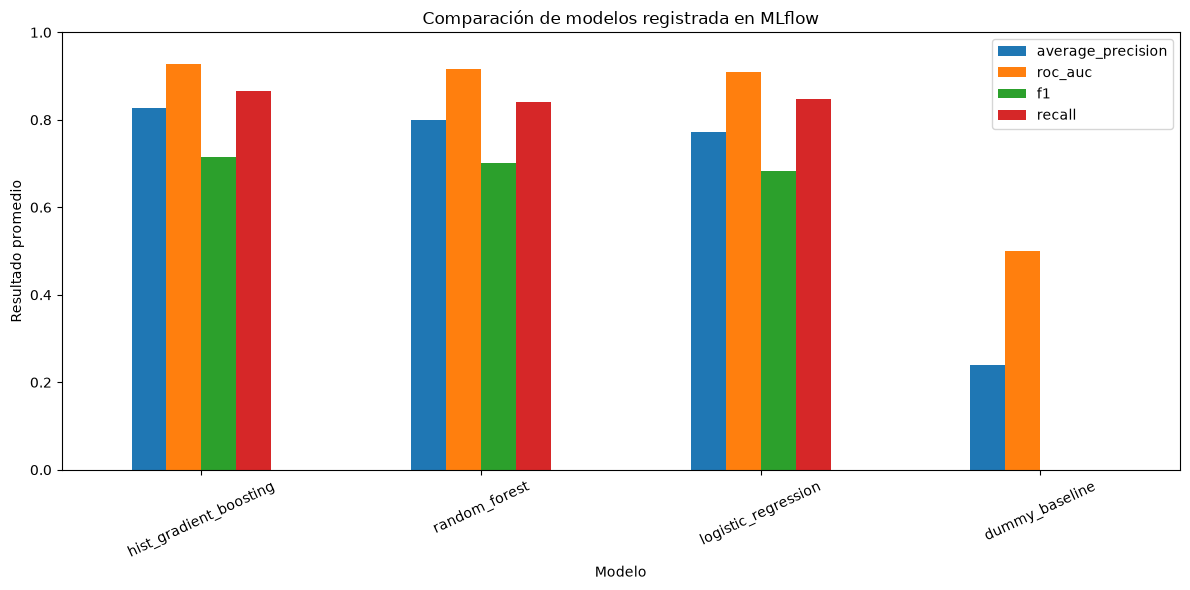

In [36]:
ax = comparacion_cv.set_index('modelo')[
    ['average_precision', 'roc_auc', 'f1', 'recall']
].plot(
    kind='bar',
    figsize=(12, 6),
    ylim=(0, 1),
    title='Comparación de modelos registrada en MLflow',
)

ax.set_xlabel('Modelo')
ax.set_ylabel('Resultado promedio')
ax.tick_params(axis='x', rotation=25)
ax.figure.tight_layout()

### Decisión de selección

HistGradientBoosting fue seleccionado porque obtuvo el mayor Average Precision promedio en validación cruzada. El test no se utilizó para elegir el algoritmo.

## 8. Run del modelo seleccionado

El run final registra el modelo elegido, el umbral calculado con predicciones out-of-fold y las métricas obtenidas una sola vez sobre test.

In [38]:
run_seleccionado_id = RUN_IDS_SESION['selected_model']
run_seleccionado = cliente_mlflow.get_run(run_seleccionado_id)

resumen_modelo_seleccionado = pd.Series({
    'run_id': run_seleccionado_id,
    'nombre_del_run': run_seleccionado.data.tags.get('mlflow.runName'),
    'algoritmo': run_seleccionado.data.params.get('algorithm'),
    'feature_set': run_seleccionado.data.params.get('feature_set'),
    'random_seed': run_seleccionado.data.params.get('random_seed'),
    'data_version': run_seleccionado.data.params.get('data_version'),
    'métrica_de_selección': run_seleccionado.data.params.get('selection_metric'),
    'objetivo_del_umbral': run_seleccionado.data.params.get('threshold_objective'),
    'umbral': run_seleccionado.data.params.get('selected_threshold'),
}, name='valor').to_frame()

display(resumen_modelo_seleccionado)

,valor
run_id,4c5d5fd38b95454caf17f1da24795e1d
nombre_del_run,selected_hist_gradient_boosting
algoritmo,hist_gradient_boosting
feature_set,adult_eda_v1
random_seed,42
data_version,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...
métrica_de_selección,average_precision
objetivo_del_umbral,f1
umbral,0.6449999999999999


In [39]:
metricas_test = pd.Series(
    run_seleccionado.data.metrics,
    name='resultado',
).to_frame()

display(metricas_test.round(4))

,resultado
test_threshold,0.6450
test_precision,0.6848
test_recall,0.7868
test_f1,0.7323
test_roc_auc,0.9332
test_average_precision,0.8407
test_balanced_accuracy,0.8364


## 9. Artefactos del run seleccionado

La evidencia debe incluir el modelo, configuración, comparación, matriz de confusión, curvas, métricas, predicciones y análisis por subgrupos.

In [40]:
def listar_artefactos(run_id, ruta=''):
    filas = []

    for artefacto in cliente_mlflow.list_artifacts(run_id, ruta):
        filas.append({
            'ruta': artefacto.path,
            'es_directorio': artefacto.is_dir,
            'tamaño_bytes': artefacto.file_size,
        })

        if artefacto.is_dir:
            filas.extend(listar_artefactos(run_id, artefacto.path))

    return filas


artefactos = pd.DataFrame(
    listar_artefactos(run_seleccionado_id)
)

display(artefactos)

,ruta,es_directorio,tamaño_bytes
0,evaluation,True,NaN
1,evaluation/busqueda_umbral_oof.csv,False,13159.0
2,evaluation/comparacion_modelos_cv.csv,False,2590.0
3,evaluation/configuracion_ml.json,False,1137.0
4,evaluation/curvas_roc_pr.png,False,68281.0
5,evaluation/manifest_modelo.json,False,1757.0
6,evaluation/matriz_confusion.csv,False,50.0
7,evaluation/matriz_confusion.png,False,34467.0
8,evaluation/metricas_subgrupos_sex.csv,False,425.0
9,evaluation/metricas_test.json,False,259.0


### Visualización de artefactos relevantes

Los gráficos también están disponibles localmente en `resultado_pipeline/modelo/`.

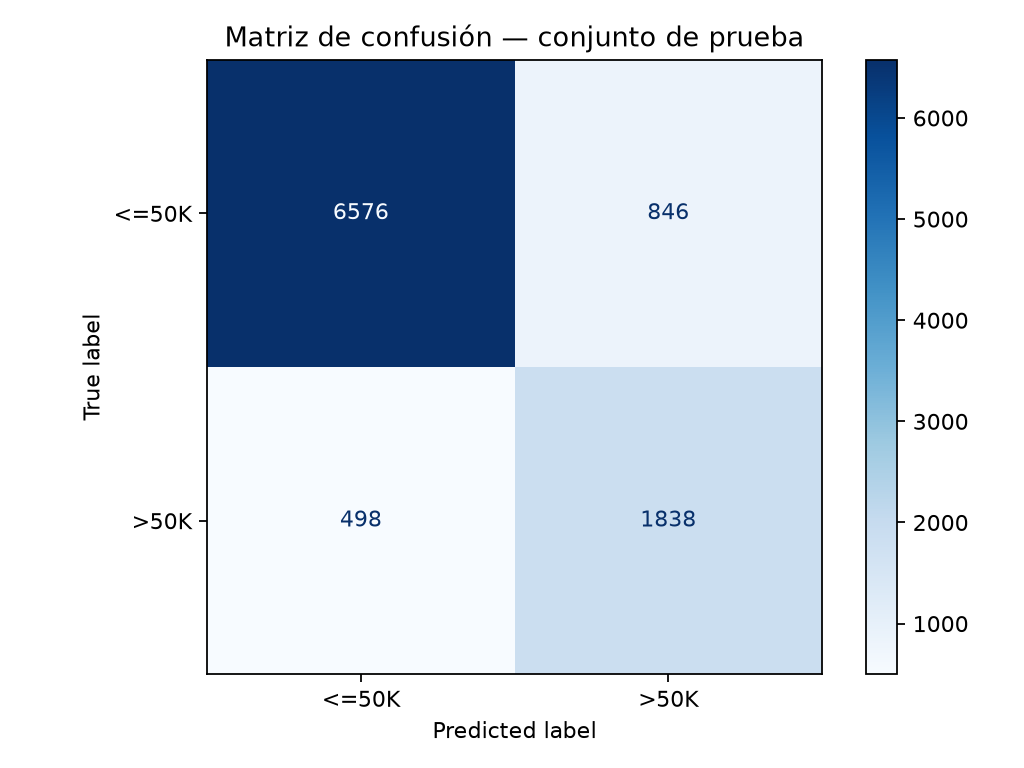

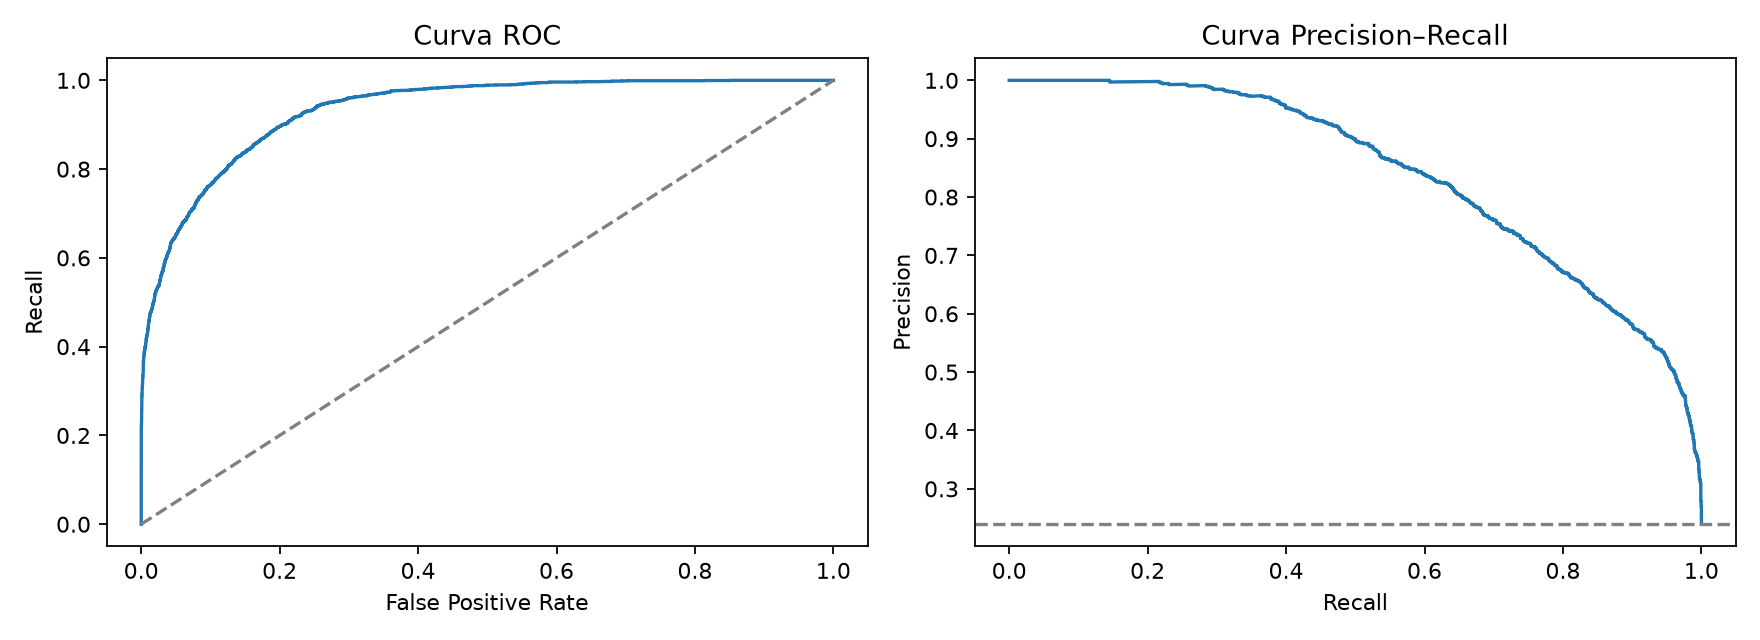

In [41]:
ML_OUTPUT_DIR = PROJECT_ROOT / 'resultado_pipeline' / 'modelo'

display(Image(filename=str(ML_OUTPUT_DIR / 'matriz_confusion.png')))
display(Image(filename=str(ML_OUTPUT_DIR / 'curvas_roc_pr.png')))

## 10. Model Registry

El modelo seleccionado debe aparecer como una versión de `adult-income-classifier`. La relación con el `run_id` permite regresar desde la versión registrada hasta los parámetros, datos, métricas y artefactos que la produjeron.

In [42]:
versiones = cliente_mlflow.search_model_versions(
    f"name='{REGISTERED_MODEL_NAME}'"
)

registro_versiones = pd.DataFrame([
    {
        'nombre': version.name,
        'versión': version.version,
        'run_id': version.run_id,
        'estado': version.status,
        'fecha_creación': pd.to_datetime(
            version.creation_timestamp, unit='ms', utc=True
        ),
    }
    for version in versiones
])

display(registro_versiones.sort_values('versión', ascending=False))
assert not registro_versiones.empty, 'El modelo no aparece en Model Registry.'
assert run_seleccionado_id in registro_versiones['run_id'].values, (
    'La sesión seleccionada no está relacionada con una versión registrada.'
)

,nombre,versión,run_id,estado,fecha_creación
0,adult-income-classifier,7,4c5d5fd38b95454caf17f1da24795e1d,READY,2026-08-27 07:10:50.771000+00:00
1,adult-income-classifier,6,663e95e7662c477681c594b8e83b5b5c,READY,2026-08-27 07:00:18.349000+00:00
2,adult-income-classifier,5,35d15804aa164e69963317aa04f620ea,READY,2026-08-27 03:45:37.853000+00:00
3,adult-income-classifier,4,b69f010678d041a4999a796753c9da0d,READY,2026-08-27 03:11:48.237000+00:00
4,adult-income-classifier,3,66e34506205d4d9f81f0aa49eb4b33a7,READY,2026-08-27 02:41:19.065000+00:00
5,adult-income-classifier,2,0043f063031645e0a605a840714fb617,READY,2026-08-27 02:08:15.080000+00:00
6,adult-income-classifier,1,97f1b722b3d1421a8d92cab4d71069b4,READY,2026-08-27 01:47:05.737000+00:00


## 11. Matriz de trazabilidad

Esta matriz resume la evidencia necesaria para responder qué produjo el modelo.

In [43]:
matriz_trazabilidad = pd.DataFrame([
    {
        'elemento': 'Datos',
        'evidencia': run_seleccionado.data.params.get('data_version'),
        'ubicación': 'params.data_version / manifest_modelo.json',
    },
    {
        'elemento': 'Features',
        'evidencia': run_seleccionado.data.params.get('feature_set'),
        'ubicación': 'params.feature_set / pipeline serializado',
    },
    {
        'elemento': 'Algoritmo',
        'evidencia': run_seleccionado.data.params.get('algorithm'),
        'ubicación': 'params.algorithm',
    },
    {
        'elemento': 'Configuración',
        'evidencia': 'Semilla, criterio de selección y umbral',
        'ubicación': 'parámetros y evaluation/configuracion_ml.json',
    },
    {
        'elemento': 'Métricas',
        'evidencia': 'Precision, Recall, F1, ROC-AUC, PR-AUC y Balanced Accuracy',
        'ubicación': 'métricas del run y evaluation/metricas_test.json',
    },
    {
        'elemento': 'Modelo',
        'evidencia': REGISTERED_MODEL_NAME,
        'ubicación': 'artefacto model y Model Registry',
    },
])

display(matriz_trazabilidad)

,elemento,evidencia,ubicación
0,Datos,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...,params.data_version / manifest_modelo.json
1,Features,adult_eda_v1,params.feature_set / pipeline serializado
2,Algoritmo,hist_gradient_boosting,params.algorithm
3,Configuración,"Semilla, criterio de selección y umbral",parámetros y evaluation/configuracion_ml.json
4,Métricas,"Precision, Recall, F1, ROC-AUC, PR-AUC y Balan...",métricas del run y evaluation/metricas_test.json
5,Modelo,adult-income-classifier,artefacto model y Model Registry


## 12. Abrir la interfaz de MLflow

Desde una terminal ubicada en la raíz del proyecto, ejecute:

```powershell
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Después abra `http://127.0.0.1:5000`. En la interfaz se deben capturar como evidencia la lista de runs, la comparación, los parámetros y métricas del run seleccionado, sus artefactos y la versión registrada del modelo.

## 13. Conclusión

Los experimentos relevantes quedan separados en runs comparables. HistGradientBoosting se selecciona mediante Average Precision de validación cruzada y posteriormente se evalúa sobre test. El run final conserva la versión de datos, configuración, métricas y artefactos, mientras que Model Registry mantiene la relación entre el modelo registrado y el run que lo produjo.